# Experiment 3: Deep Neural Network with Hyperparameter Tuning

**Course:** AML ZC417 – Introduction to Deep Learning
**Module Reference:** Module 4 — Deep Feedforward Neural Networks
**Duration:** 2 hours

---

## Aim
To build, train, and evaluate a Deep Feedforward Neural Network (DNN) for a classification task, and to study the effect of key hyperparameters — number of hidden layers, number of neurons, activation function, learning rate, batch size, and number of epochs — on model performance.

## Learning Outcomes
By the end of this experiment, you will be able to:
1. Build a multi-layer feedforward neural network using Keras (TensorFlow) and PyTorch.
2. Compile and train a DNN using an appropriate loss function and optimizer.
3. Evaluate a trained model using accuracy and loss curves on training and validation data.
4. Explain the effect of network depth and width on model performance.
5. Explain the effect of learning rate and batch size on training convergence.
6. Systematically tune hyperparameters and select the best-performing configuration.


## Part 0 — Setup and Dataset

We will use the **MNIST handwritten digits dataset** (28×28 grayscale images, 10 classes: digits 0–9). It is small, fast to train on a CPU, and lets us focus on the effect of hyperparameters rather than on data preprocessing.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import torch
import torch.nn as nn
import torch.optim as optim

print("TensorFlow version:", tf.__version__)
print("PyTorch version:", torch.__version__)

tf.random.set_seed(42)
torch.manual_seed(42)
np.random.seed(42)


TensorFlow version: 2.21.0
PyTorch version: 2.13.0+cpu


In [8]:
# Load MNIST
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1] and flatten 28x28 images to 784-length vectors
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train_full = x_train_full.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Hold out a validation set from the training data
x_train, x_val = x_train_full[:50000], x_train_full[50000:]
y_train, y_val = y_train_full[:50000], y_train_full[50000:]

print("Train shape:", x_train.shape, y_train.shape)
print("Validation shape:", x_val.shape, y_val.shape)
print("Test shape:", x_test.shape, y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step 
Train shape: (50000, 784) (50000,)
Validation shape: (10000, 784) (10000,)
Test shape: (10000, 784) (10000,)


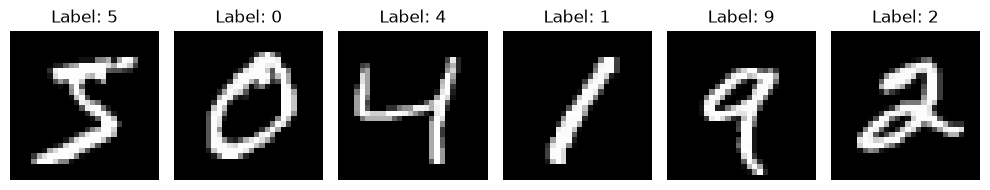

In [9]:
# Visualize a few samples
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()


---
## Part 1 — Building a Baseline DNN (TensorFlow / Keras)

We start with a simple baseline: two hidden layers, ReLU activation, Adam optimizer. This becomes our **reference point** for the hyperparameter experiments that follow.


In [10]:
def build_keras_model(hidden_layers=[128, 64], activation="relu", learning_rate=0.001):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(784,)))
    for units in hidden_layers:
        model.add(keras.layers.Dense(units, activation=activation))
    model.add(keras.layers.Dense(10, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

baseline_model = build_keras_model()
baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history_baseline = baseline_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=2,
)


Epoch 1/10
1563/1563 - 3s - 2ms/step - accuracy: 0.9208 - loss: 0.2669 - val_accuracy: 0.9616 - val_loss: 0.1318
Epoch 2/10
1563/1563 - 2s - 2ms/step - accuracy: 0.9659 - loss: 0.1118 - val_accuracy: 0.9718 - val_loss: 0.0978
Epoch 3/10
1563/1563 - 2s - 1ms/step - accuracy: 0.9776 - loss: 0.0741 - val_accuracy: 0.9696 - val_loss: 0.1011
Epoch 4/10
1563/1563 - 2s - 1ms/step - accuracy: 0.9839 - loss: 0.0533 - val_accuracy: 0.9708 - val_loss: 0.1016
Epoch 5/10
1563/1563 - 3s - 2ms/step - accuracy: 0.9877 - loss: 0.0410 - val_accuracy: 0.9706 - val_loss: 0.1131
Epoch 6/10
1563/1563 - 2s - 1ms/step - accuracy: 0.9899 - loss: 0.0330 - val_accuracy: 0.9695 - val_loss: 0.1251
Epoch 7/10
1563/1563 - 2s - 1ms/step - accuracy: 0.9916 - loss: 0.0255 - val_accuracy: 0.9687 - val_loss: 0.1287
Epoch 8/10
1563/1563 - 2s - 1ms/step - accuracy: 0.9919 - loss: 0.0234 - val_accuracy: 0.9700 - val_loss: 0.1300
Epoch 9/10
1563/1563 - 2s - 1ms/step - accuracy: 0.9930 - loss: 0.0211 - val_accuracy: 0.9754 - 

In [12]:
test_loss, test_acc = baseline_model.evaluate(x_test, y_test, verbose=0)
print(f"Baseline model -- Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")


Baseline model -- Test accuracy: 0.9744, Test loss: 0.1211


### 1.1 Plotting Training Curves

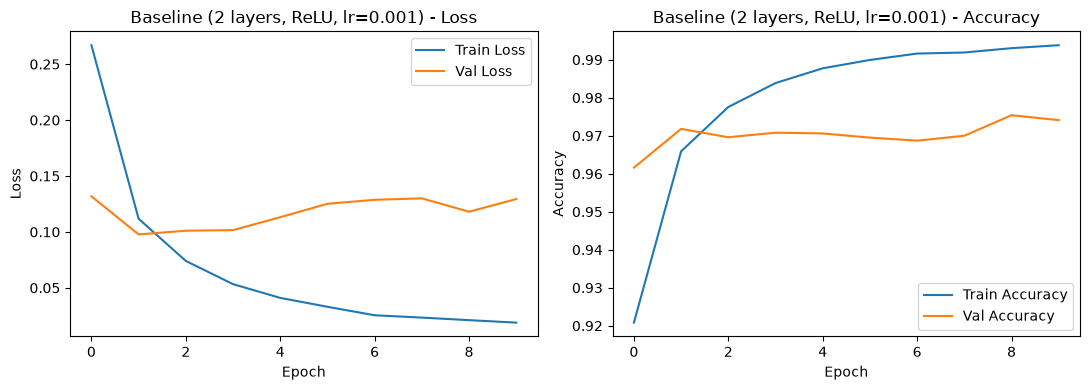

In [13]:
def plot_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history.history["loss"], label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Val Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].set_title(f"{title} - Loss")

    axes[1].plot(history.history["accuracy"], label="Train Accuracy")
    axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend(); axes[1].set_title(f"{title} - Accuracy")
    plt.tight_layout()
    plt.show()

plot_history(history_baseline, "Baseline (2 layers, ReLU, lr=0.001)")


**What to look for:** If training loss keeps falling while validation loss flattens or rises, the model is starting to overfit — a concept covered in depth in Module 6 (Regularization). For now, simply note the general shape of the curves.


---
## Part 2 — Building the Same DNN in PyTorch

We now build the equivalent architecture in PyTorch, to see how the same model is expressed in both frameworks.


In [14]:
class DNN(nn.Module):
    def __init__(self, input_dim=784, hidden_layers=[128, 64], num_classes=10):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for units in hidden_layers:
            layers.append(nn.Linear(prev_dim, units))
            layers.append(nn.ReLU())
            prev_dim = units
        layers.append(nn.Linear(prev_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)   # raw logits -- softmax handled by the loss function

model_pt = DNN()
print(model_pt)


DNN(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [15]:
# Convert NumPy arrays to PyTorch tensors
x_train_t = torch.tensor(x_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
x_val_t = torch.tensor(x_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
x_test_t = torch.tensor(x_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_dataset = torch.utils.data.TensorDataset(x_train_t, y_train_t)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)


In [16]:
def train_pytorch_model(model, train_loader, x_val_t, y_val_t, epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()   # combines softmax + cross-entropy
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            correct += (outputs.argmax(dim=1) == yb).sum().item()
            total += xb.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        with torch.no_grad():
            val_outputs = model(x_val_t)
            val_loss = criterion(val_outputs, y_val_t).item()
            val_acc = (val_outputs.argmax(dim=1) == y_val_t).float().mean().item()

        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

    return history

history_pt = train_pytorch_model(model_pt, train_loader, x_val_t, y_val_t, epochs=10, lr=0.001)


Epoch 1/10 - loss: 0.3096 - accuracy: 0.9103 - val_loss: 0.1677 - val_accuracy: 0.9515
Epoch 2/10 - loss: 0.1318 - accuracy: 0.9607 - val_loss: 0.1264 - val_accuracy: 0.9631
Epoch 3/10 - loss: 0.0899 - accuracy: 0.9721 - val_loss: 0.0946 - val_accuracy: 0.9727
Epoch 4/10 - loss: 0.0665 - accuracy: 0.9792 - val_loss: 0.0822 - val_accuracy: 0.9759
Epoch 5/10 - loss: 0.0523 - accuracy: 0.9832 - val_loss: 0.0977 - val_accuracy: 0.9717
Epoch 6/10 - loss: 0.0409 - accuracy: 0.9870 - val_loss: 0.0883 - val_accuracy: 0.9746
Epoch 7/10 - loss: 0.0324 - accuracy: 0.9893 - val_loss: 0.0903 - val_accuracy: 0.9762
Epoch 8/10 - loss: 0.0267 - accuracy: 0.9910 - val_loss: 0.0918 - val_accuracy: 0.9765
Epoch 9/10 - loss: 0.0235 - accuracy: 0.9923 - val_loss: 0.0919 - val_accuracy: 0.9761
Epoch 10/10 - loss: 0.0210 - accuracy: 0.9934 - val_loss: 0.0932 - val_accuracy: 0.9776


In [17]:
model_pt.eval()
with torch.no_grad():
    test_outputs = model_pt(x_test_t)
    test_acc_pt = (test_outputs.argmax(dim=1) == y_test_t).float().mean().item()
print(f"PyTorch baseline model -- Test accuracy: {test_acc_pt:.4f}")


PyTorch baseline model -- Test accuracy: 0.9777


**Note:** PyTorch's `nn.CrossEntropyLoss` expects raw logits and internally applies `log_softmax`, so the model's final layer does **not** include a softmax activation — unlike the Keras model, whose output layer explicitly applies `softmax`. Both are mathematically equivalent.


---
## Part 3 — Hyperparameter Tuning

We now systematically vary hyperparameters **one at a time** and observe the effect on validation accuracy, using the Keras model for speed of iteration. In each case, all other hyperparameters are held at the baseline (`hidden_layers=[128, 64]`, `activation="relu"`, `learning_rate=0.001`, `batch_size=32`, `epochs=10`).

### 3.1 Effect of Network Depth (Number of Hidden Layers)


In [18]:
depth_configs = {
    "1 layer":  [128],
    "2 layers": [128, 64],
    "4 layers": [256, 128, 64, 32],
}

depth_results = {}
for name, layers_config in depth_configs.items():
    print(f"\nTraining: {name} {layers_config}")
    m = build_keras_model(hidden_layers=layers_config)
    h = m.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=10, batch_size=32, verbose=0)
    depth_results[name] = h.history["val_accuracy"][-1]
    print(f"{name}: final val_accuracy = {depth_results[name]:.4f}")

print("\nSummary:", depth_results)



Training: 1 layer [128]
1 layer: final val_accuracy = 0.9700

Training: 2 layers [128, 64]
2 layers: final val_accuracy = 0.9764

Training: 4 layers [256, 128, 64, 32]
4 layers: final val_accuracy = 0.9718

Summary: {'1 layer': 0.9700000286102295, '2 layers': 0.9764000177383423, '4 layers': 0.9718000292778015}


### 3.2 Effect of Activation Function

In [19]:
activation_configs = ["relu", "tanh", "sigmoid"]

activation_results = {}
for act in activation_configs:
    print(f"\nTraining with activation: {act}")
    m = build_keras_model(hidden_layers=[128, 64], activation=act)
    h = m.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=10, batch_size=32, verbose=0)
    activation_results[act] = h.history["val_accuracy"][-1]
    print(f"{act}: final val_accuracy = {activation_results[act]:.4f}")

print("\nSummary:", activation_results)



Training with activation: relu
relu: final val_accuracy = 0.9779

Training with activation: tanh
tanh: final val_accuracy = 0.9745

Training with activation: sigmoid
sigmoid: final val_accuracy = 0.9748

Summary: {'relu': 0.9779000282287598, 'tanh': 0.9745000004768372, 'sigmoid': 0.9747999906539917}


### 3.3 Effect of Learning Rate

In [20]:
lr_configs = [0.1, 0.001, 0.0001]

lr_results = {}
for lr in lr_configs:
    print(f"\nTraining with learning_rate={lr}")
    m = build_keras_model(hidden_layers=[128, 64], learning_rate=lr)
    h = m.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=10, batch_size=32, verbose=0)
    lr_results[lr] = h.history["val_accuracy"][-1]
    print(f"lr={lr}: final val_accuracy = {lr_results[lr]:.4f}")

print("\nSummary:", lr_results)



Training with learning_rate=0.1
lr=0.1: final val_accuracy = 0.2004

Training with learning_rate=0.001
lr=0.001: final val_accuracy = 0.9745

Training with learning_rate=0.0001
lr=0.0001: final val_accuracy = 0.9662

Summary: {0.1: 0.2003999948501587, 0.001: 0.9745000004768372, 0.0001: 0.9661999940872192}


**What to look for:** A learning rate that is too high (e.g. 0.1) often causes unstable or oscillating training, while one that is too low (e.g. 0.0001) converges very slowly and may not reach a good accuracy within a fixed number of epochs.


### 3.4 Effect of Batch Size

In [21]:
batch_configs = [16, 32, 128]

batch_results = {}
for bs in batch_configs:
    print(f"\nTraining with batch_size={bs}")
    m = build_keras_model(hidden_layers=[128, 64])
    h = m.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=10, batch_size=bs, verbose=0)
    batch_results[bs] = h.history["val_accuracy"][-1]
    print(f"batch_size={bs}: final val_accuracy = {batch_results[bs]:.4f}")

print("\nSummary:", batch_results)



Training with batch_size=16
batch_size=16: final val_accuracy = 0.9782

Training with batch_size=32
batch_size=32: final val_accuracy = 0.9764

Training with batch_size=128
batch_size=128: final val_accuracy = 0.9711

Summary: {16: 0.9782000184059143, 32: 0.9764000177383423, 128: 0.9710999727249146}


**What to look for:** Smaller batch sizes generally take longer per epoch (more updates) but can generalize slightly better; larger batch sizes train faster per epoch but may need a higher learning rate to converge equally well.


---
## Part 4 — Visualizing the Hyperparameter Sweep


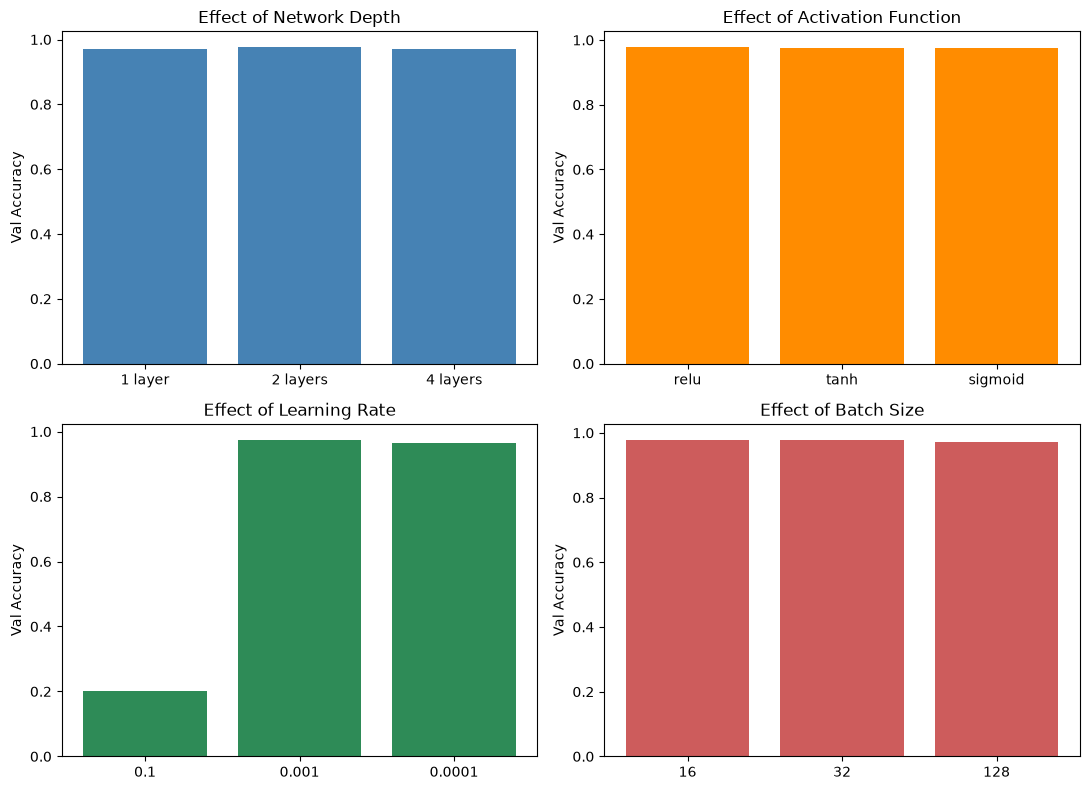

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0,0].bar(depth_results.keys(), depth_results.values(), color="steelblue")
axes[0,0].set_title("Effect of Network Depth"); axes[0,0].set_ylabel("Val Accuracy")

axes[0,1].bar(activation_results.keys(), activation_results.values(), color="darkorange")
axes[0,1].set_title("Effect of Activation Function"); axes[0,1].set_ylabel("Val Accuracy")

axes[1,0].bar([str(k) for k in lr_results.keys()], lr_results.values(), color="seagreen")
axes[1,0].set_title("Effect of Learning Rate"); axes[1,0].set_ylabel("Val Accuracy")

axes[1,1].bar([str(k) for k in batch_results.keys()], batch_results.values(), color="indianred")
axes[1,1].set_title("Effect of Batch Size"); axes[1,1].set_ylabel("Val Accuracy")

plt.tight_layout()
plt.show()


---
## Part 5 — Selecting and Evaluating the Best Configuration

Based on the sweep above, choose the best-performing value for each hyperparameter, combine them into a single "best" configuration, train it, and evaluate it on the **held-out test set** (used only once, at the very end).


In [23]:
# Example: combine the best-performing settings found above.
# Replace these with the values YOU found best in Part 3.
best_hidden_layers = [128, 64]
best_activation = "relu"
best_lr = 0.001
best_batch_size = 32

best_model = build_keras_model(hidden_layers=best_hidden_layers, activation=best_activation, learning_rate=best_lr)
history_best = best_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=best_batch_size,
    verbose=2,
)

test_loss_best, test_acc_best = best_model.evaluate(x_test, y_test, verbose=0)
print(f"\nBest model -- Test accuracy: {test_acc_best:.4f}, Test loss: {test_loss_best:.4f}")


Epoch 1/15
1563/1563 - 3s - 2ms/step - accuracy: 0.9204 - loss: 0.2699 - val_accuracy: 0.9592 - val_loss: 0.1344
Epoch 2/15
1563/1563 - 3s - 2ms/step - accuracy: 0.9666 - loss: 0.1094 - val_accuracy: 0.9677 - val_loss: 0.1020
Epoch 3/15
1563/1563 - 3s - 2ms/step - accuracy: 0.9778 - loss: 0.0740 - val_accuracy: 0.9696 - val_loss: 0.1017
Epoch 4/15
1563/1563 - 3s - 2ms/step - accuracy: 0.9839 - loss: 0.0537 - val_accuracy: 0.9742 - val_loss: 0.0889
Epoch 5/15
1563/1563 - 3s - 2ms/step - accuracy: 0.9881 - loss: 0.0394 - val_accuracy: 0.9738 - val_loss: 0.1030
Epoch 6/15
1563/1563 - 3s - 2ms/step - accuracy: 0.9904 - loss: 0.0300 - val_accuracy: 0.9758 - val_loss: 0.0944
Epoch 7/15
1563/1563 - 3s - 2ms/step - accuracy: 0.9917 - loss: 0.0256 - val_accuracy: 0.9747 - val_loss: 0.1085
Epoch 8/15
1563/1563 - 2s - 1ms/step - accuracy: 0.9927 - loss: 0.0233 - val_accuracy: 0.9731 - val_loss: 0.1123
Epoch 9/15
1563/1563 - 3s - 2ms/step - accuracy: 0.9928 - loss: 0.0211 - val_accuracy: 0.9752 - 

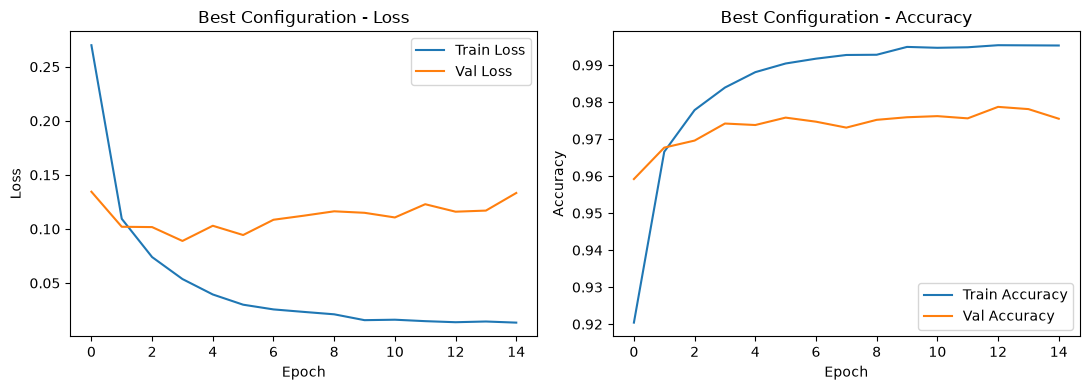

In [24]:
plot_history(history_best, "Best Configuration")


---
## Part 6 — In-Lab Exercise (to be completed and shown to the instructor)

Using the code above as a template:

1. Run the network-depth sweep with **one additional configuration**: `[512, 256, 128, 64, 32]` (5 layers). Does accuracy keep improving with more layers, or does it plateau/worsen? Explain in a markdown cell.
2. Train a model with a **very high learning rate (1.0)** for 10 epochs and observe the loss curve. Describe what happens and why.
3. Build the **same "best" architecture from Part 5 in PyTorch** (using the `DNN` class and `train_pytorch_model` function from Part 2) and report its test accuracy. Is it close to the Keras result?
4. In 2–3 sentences, summarize which single hyperparameter had the **largest** effect on validation accuracy in your experiments, and which had the **smallest**.


In [25]:
# TODO 1: 5-layer network depth experiment
# your code here


_TODO 1 (continued): Your explanation here._

In [26]:
# TODO 2: Very high learning rate (1.0) experiment
# your code here


_TODO 2 (continued): Your explanation here._

In [27]:
# TODO 3: Best architecture in PyTorch
# your code here


_TODO 4: Your summary here._

---
## Post-Lab Viva Questions

1. What is the role of the activation function in a hidden layer? What would happen if all activations were removed (i.e. purely linear layers)?
2. Why does the final layer use `softmax` (Keras) while PyTorch's `CrossEntropyLoss` does not require an explicit softmax in the model?
3. What is the difference between an epoch, a batch, and an iteration?
4. Explain, in your own words, why a learning rate that is too large can prevent a network from converging.
5. If increasing network depth does not improve validation accuracy, what could be the reason, and what would you try next?
6. What is the difference between training accuracy and validation accuracy, and why do we track both?

---
*End of Experiment 3*
